# テーマ7 クラスタリング

## 目的
- クラスタリングが「正解ラベルなしで構造を探す」教師なし学習であることを理解する
- Wine データセットに k-means を適用し、似たデータをグループ化する
- エルボー法とシルエットスコアで最適なクラスタ数を選ぶ方法を体験する
- クラスタ番号に最初から意味があるわけではなく、後から特徴を見て意味づけすることを理解する
- （発展）PCA により高次元データを2次元で可視化する

## 今日の成果物
- エルボー法またはシルエットスコアで、適切なクラスタ数を選ぶ
- クラスタごとの特徴や真のラベルとの違いを短く説明する
- （発展）PCA の散布図を作る

## クラスタリングの基本

クラスタリングは、正解ラベルを使わずに、似ているデータ同士をグループ化する方法です。分類とは違い、最初から「正解のクラス」を教えません。

k-means では、各データ点を最も近いクラスタ中心に割り当て、中心を更新することを繰り返します。目的は、クラスタ内のばらつきを小さくすることです。

$$
\sum_{k=1}^{K}\sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

ここで、$C_k$ はクラスタ、$\mu_k$ はクラスタ中心です。


### 教師あり学習との違い

分類では、正解ラベルを使って「この入力ならこのクラス」と学習しました。クラスタリングでは、正解ラベルを使わずに、特徴量だけから似ているデータをまとめます。

そのため、クラスタ番号は答えではありません。クラスタごとの平均値や元のラベルとの対応を見て、後から「このクラスタは何が特徴的か」を考えます。


### Step 0: ライブラリを読み込む
クラスタリングに必要なライブラリを読み込みます。標準化、k-means、PCA を使う準備を整えます。

### Step 0: クラスタリングの流れを確認する
このノートブックでは、Wine データを使って教師なし学習の基本を体験します。標準化、k-means、クラスタの比較を順番に試し、PCA は必要に応じて使う発展内容として扱います。

In [1]:
# ===== Step 0: ライブラリ読み込み =====
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']


### Step 1: データを読み込む
Wine データセットを読み込み、クラスタリング対象のデータ構造を確認します。まずは先頭行と行数・列数を見て全体像を把握します。


In [2]:
# ===== Step 1: データ読み込み =====
# TODO: WineデータセットをDataFrameにする
wine = load_wine(as_frame=True)
df = wine.frame.copy()

print('行数, 列数 =', df.shape)
display(df.head())

行数, 列数 = (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Step 2: 標準化する
特徴量のスケールをそろえてからクラスタリングを行います。距離ベースの手法では、この前処理が結果に大きく影響します。

#### 解説: なぜ標準化するのか

k-means は距離にもとづいてグループを作ります。値のスケールが大きい特徴量があると、その特徴量だけが距離を強く支配してしまいます。

そのため、各特徴量を平均0、標準偏差1にそろえます。

$$
z = \frac{x - \mu}{\sigma}
$$

距離ベースの手法では、標準化は結果に大きく影響します。


In [3]:
# ===== Step 2: 標準化 =====
# TODO: target を除いた特徴量だけを使う
feature_columns = wine.feature_names
X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('標準化後の形 =', X_scaled.shape)

標準化後の形 = (178, 13)


### Step 3: k-means を実行する
クラスタ数を指定して、データを自動でグループ分けします。結果のラベルを見て、元の分類と比べてみてください。

#### 解説: クラスタ番号の注意

k-means が出す `0`, `1`, `2` という番号は、最初から意味を持っているわけではありません。例えば `cluster=0` が「高級ワイン」という意味だとは限りません。

意味づけをするには、各クラスタに含まれるデータの特徴をあとから確認します。


In [4]:
# ===== Step 3: k-means =====
# TODO: クラスタ数を変えると結果がどう変わるか試す
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels
display(df[['target', 'cluster']].head())

/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,target,cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


In [5]:
# ===== 追加演習: クラスタごとの平均値を見る =====
cluster_summary = df.groupby('cluster')[wine.feature_names].mean()
display(cluster_summary)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


### 追加演習: クラスタと真のラベルの対応を見る
クラスタ番号そのものには意味がないので、真のラベルとの対応を表で確認します。どのクラスタにどの品種が多いかを見てください。

In [6]:
cluster_target_table = pd.crosstab(df['cluster'], df['target'], rownames=['cluster'], colnames=['target'])
display(cluster_target_table)

display(pd.crosstab(df['cluster'], df['target'], normalize='index'))

target,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


target,0,1,2
cluster,,,
0,0.000000,1.000000,0.000000
1,0.000000,0.058824,0.941176
2,0.951613,0.048387,0.000000


### 追加演習: エルボー法とシルエットスコアでクラスタ数を考える
`n_clusters=3` を決め打ちにせず、k を変えたときの inertia と silhouette score を比べてみます。

/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret 

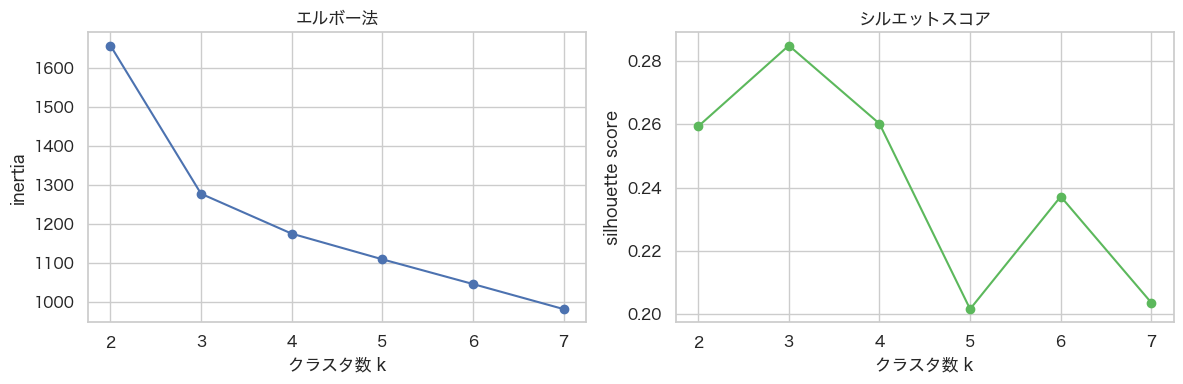

シルエットスコアが最も高かった k = 3


In [7]:
k_values = range(2, 8)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_xlabel('クラスタ数 k')
axes[0].set_ylabel('inertia')
axes[0].set_title('エルボー法')
axes[0].grid(True)

axes[1].plot(list(k_values), silhouette_scores, marker='o', color='#5CB85C')
axes[1].set_xlabel('クラスタ数 k')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('シルエットスコア')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k = list(k_values)[silhouette_scores.index(max(silhouette_scores))]
print('シルエットスコアが最も高かった k =', best_k)

### 追加演習: 標準化ありとなしを比べる
距離ベースの手法では標準化の有無で結果が変わります。PCA の前に、まずクラスタリングの結果そのものを比較してみます。

In [8]:
X_no_scale = df[feature_columns].to_numpy()

kmeans_no_scale = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_no_scale = kmeans_no_scale.fit_predict(X_no_scale)

comparison_df = pd.DataFrame({
    'standardized': df['cluster'],
    'not_standardized': labels_no_scale,
    'target': df['target'],
})

display(pd.crosstab(comparison_df['standardized'], comparison_df['target'], rownames=['standardized cluster'], colnames=['target']))
display(pd.crosstab(comparison_df['not_standardized'], comparison_df['target'], rownames=['not standardized cluster'], colnames=['target']))

print('標準化あり inertia =', kmeans.inertia_)
print('標準化なし inertia =', kmeans_no_scale.inertia_)

/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


target,0,1,2
standardized cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


target,0,1,2
not standardized cluster,,,
0,13,20,29
1,46,1,0
2,0,50,19


標準化あり inertia = 1277.928488844642
標準化なし inertia = 2370689.686782968


### 発展: PCA で可視化する
必要なら高次元データを2次元に圧縮して、クラスタと真のラベルの見え方を比べます。PCA は必須ではなく、発展として扱います。

#### 発展: PCA による2次元可視化

Wine データには多くの特徴量があるため、そのままでは散布図にできません。PCA は、情報をできるだけ残しながら高次元データを少数の軸にまとめる方法です。

第1主成分は、データのばらつきが最も大きくなる方向です。第2主成分は、第1主成分と直交し、その次にばらつきが大きい方向です。

PCA の散布図は便利ですが、元の情報をすべて保っているわけではない点に注意します。ここは発展内容なので、余裕があれば取り組んでください。

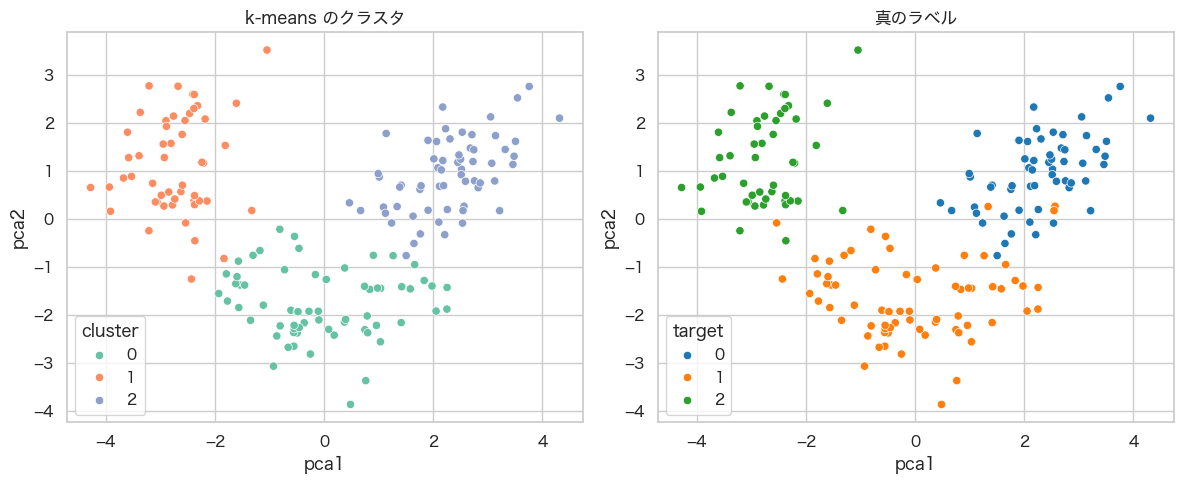

In [9]:
# ===== Step 4: PCAで可視化 =====
# TODO: 2次元に圧縮して散布図を描く
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['cluster'],
    'target': df['target'],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=plot_df, x='pca1', y='pca2', hue='cluster', palette='Set2', ax=axes[0])
axes[0].set_title('k-means のクラスタ')

sns.scatterplot(data=plot_df, x='pca1', y='pca2', hue='target', palette='tab10', ax=axes[1])
axes[1].set_title('真のラベル')

plt.tight_layout()
plt.show()

In [10]:
# ===== 追加演習: PCAがどれくらい情報を残しているか確認する =====
explained = pca.explained_variance_ratio_
print('第1主成分の寄与率:', explained[0])
print('第2主成分の寄与率:', explained[1])
print('2次元で説明できる割合:', explained.sum())


第1主成分の寄与率: 0.36198848099926323
第2主成分の寄与率: 0.19207490257008944
2次元で説明できる割合: 0.5540633835693527


## 振り返り
- クラスタと真のラベルはどの程度似ていましたか。
- `n_clusters` を変えると、どんな違いがありましたか。
- エルボー法とシルエットスコアでは、どの k がよさそうでしたか。
- 標準化ありとなしで、結果はどう変わりましたか。
- クラスタ番号に意味をつけるには、何を確認する必要がありますか。
- 教師あり学習と教師なし学習の違いを自分の言葉で説明してください。

## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: クラスタ数の影響 (簡単)

1. `n_clusters` を 2, 3, 4, 5 と変えて k-means を実行し、それぞれの inertia（慣性）を確認してください。
2. エルボー法で最適なクラスタ数はどれだと判断できますか。理由を書いてください。

```python
# ここにコードを書いてください
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2, 6)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

# エルボープロット
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.grid(True)
plt.show()
```

### 演習2: クラスタと真のラベルの比較 (簡単)

1. Wineデータセットでは、真の品種ラベルが3つあります。k-meansで `n_clusters=3` の場合、クラスタと真のラベルはどの程度一致していますか。
2. 各クラスタに含まれる品種の割合を確認してください。

```python
# ここにコードを書いてください
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[wine.feature_names])

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# クラスタと真のラベルのクロス集計
table = pd.crosstab(cluster_labels, df['target'], margins=True)
print("クラスタ vs 真のラベル:")
print(table)
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **クラスタリングとは** (200字程度)
   - クラスタリングが教師あり学習とどのように違うか、自分の言葉で説明してください。また、クラスタリングが使われる現実世界の例を1つ挙げてください。

2. **最適なクラスタ数の選び方** (200字程度)
   - エルボー法とシルエットスコアについて説明してください。両者の結果が一致しない場合、どのように判断すればよいでしょうか。

3. **PCAによる可視化** (200字程度)
   - PCA（主成分分析）が高次元データを2次元に圧縮する意味を説明してください。また、2次元プロットからクラスタの構造について何が読み取れますか。

4. **クラスタリング結果の解釈** (300字程度)
   - Wineデータセットのクラスタリング結果について、各クラスタがどの品種に対応しているかを説明してください。また、教師なし学習で得られた結果を「意味づける」ために何を確認しましたか。

